In [3]:
from cirq_sic import *

d = 2
base_dir = "data/sky_ground"
wh_implementation = "simple"

psi_stab = np.eye(d)[0]
psi_sic = load_sic_fiducial(d)
interpolation = geodesic_interpolator(psi_stab, psi_sic)

T = np.linspace(0, 1, 15)
specs_t = {t: {"dataset_id": "1param",
               "processor_id": "willow_pink",
               "run_type": "clean",
               "qubits": get_wh_qubits(d, wh_implementation),
               "n_shots": 50000,
               "optimizer": "cirq",
               "d": d,
               "fiducial": interpolation(t),
               "fiducial_description": f"interpolation_{np.round(t, 4)}",
               "wh_implementation": wh_implementation} for t in T}

for t, specs in specs_t.items():
    run_sky_ground_tasks(specs, base_dir=base_dir)

2026-03-12 01:35:44 [INFO] 1param/d2/CharacterizeWHReferenceDeviceTask/simple/interpolation_0.0/cirq_clean_n50k_willow_pink_q4_2-5_2: Task already exists. Skipping.
2026-03-12 01:35:44 [INFO] 1param/d2/WHPOVMOnBasisStatesTask/simple/interpolation_0.0/cirq_clean_n50k_willow_pink_q4_2-5_2: Task already exists. Skipping.
2026-03-12 01:35:44 [INFO] 1param/d2/BasisMeasurementOnWHStatesTask/interpolation_0.0/cirq_clean_n50k_willow_pink_q4_2-5_2: Task already exists. Skipping.
2026-03-12 01:35:44 [INFO] 1param/d2/BasisMeasurementOnBasisStatesTask/cirq_clean_n50k_willow_pink_q4_2-5_2: Task already exists. Skipping.
2026-03-12 01:35:44 [INFO] 1param/d2/CharacterizeWHReferenceDeviceTask/simple/interpolation_0.0714/cirq_clean_n50k_willow_pink_q4_2-5_2: Task already exists. Skipping.
2026-03-12 01:35:44 [INFO] 1param/d2/WHPOVMOnBasisStatesTask/simple/interpolation_0.0714/cirq_clean_n50k_willow_pink_q4_2-5_2: Task already exists. Skipping.
2026-03-12 01:35:44 [INFO] 1param/d2/BasisMeasurementOnWHSt

In [4]:
interpolation(0), psi_stab

(array([1.+0.j, 0.+0.j]), array([1., 0.]))

In [5]:
interpolation(1)/interpolation(1)[0], psi_sic/psi_sic[0]

(array([1.   +0.j   , 0.366-0.366j]), array([1.   +0.j   , 0.366-0.366j]))

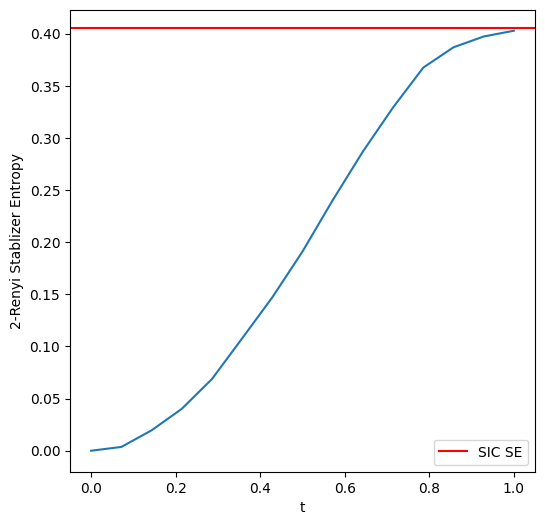

In [29]:
alpha = 2
magic_t = []
for t in T:
    tasks, sg_results = load_sky_ground_results(specs_t[t], separate=True, base_dir=None)
    chi = sg_results["P"][:,0]
    magic = (1/(1-alpha))*np.log(np.sum(chi**alpha)) - np.log(d)
    magic_t.append(magic)

max_magic = (1/(1-alpha))*np.log((1+(d-1)*(d+1)**(1-alpha))/d)

fig, ax = plt.subplots(1, figsize=(6,6))
ax.plot(T, magic_t)
ax.axhline(y=max_magic, label="SIC SE", color="red")
ax.set_xlabel("t")
ax.set_ylabel("2-Renyi Stablizer Entropy")
ax.legend()
fig.savefig("img/renyi_se.pdf")

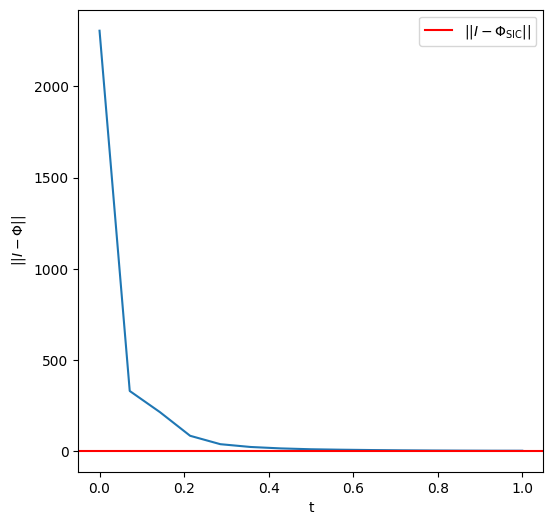

In [30]:
metrics_t = {t: sky_ground_metrics(specs_t[t]) for t in T}
fig, ax = plt.subplots(1, figsize=(6,6))
ax.plot(T, [metrics_t[t]["quantumness"] for t in T])
ax.axhline(y=np.linalg.norm(np.eye(d**2) - np.linalg.inv(SIC_P(d))), label=r"$|| I - \Phi_{\text{SIC}} ||$", color="red")
ax.set_xlabel("t")
ax.set_ylabel(r"$|| I - \Phi ||$")
ax.legend()
fig.savefig("img/quantumness.pdf")

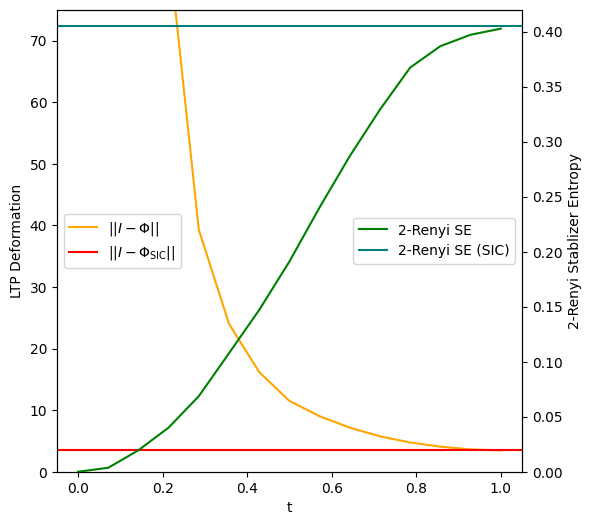

In [47]:
fig, ax = plt.subplots(1, figsize=(6,6))
ax.plot(T, [metrics_t[t]["quantumness"] for t in T], label=r"$|| I - \Phi ||$", color="orange")
ax.axhline(y=np.linalg.norm(np.eye(d**2) - np.linalg.inv(SIC_P(d))), label=r"$|| I - \Phi_{\text{SIC}} ||$", color="red")
ax.set_xlabel("t")
ax.set_ylabel(r"LTP Deformation")
ax.set_ylim(0, 75)
ax.legend(loc='center left')

ax2 = ax.twinx()
ax2.plot(T, magic_t, color="green", label="2-Renyi SE")
ax2.axhline(y=max_magic, label=r"2-Renyi SE (SIC)", color="teal")
ax2.set_xlabel("t")
ax2.set_ylabel("2-Renyi Stablizer Entropy")
ax2.legend(loc='center right')
ax2.set_ylim(0, 0.42)
fig.savefig("img/both.pdf")

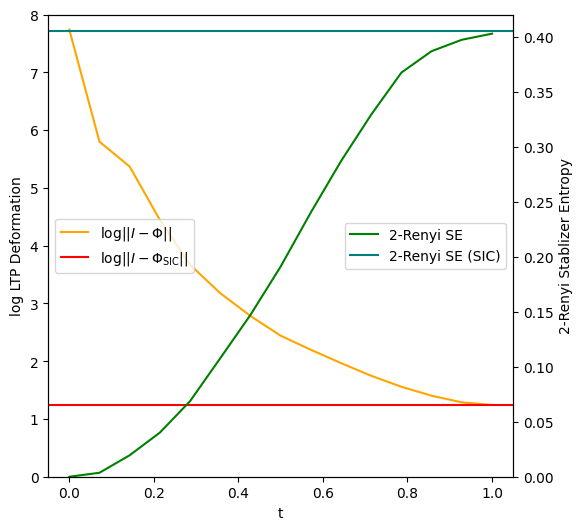

In [48]:
fig, ax = plt.subplots(1, figsize=(6,6))
ax.plot(T, [np.log(metrics_t[t]["quantumness"]) for t in T], label=r"$\log || I - \Phi ||$", color="orange")
ax.axhline(y=np.log(np.linalg.norm(np.eye(d**2) - np.linalg.inv(SIC_P(d)))), label=r"$\log || I - \Phi_{\text{SIC}} ||$", color="red")
ax.set_xlabel("t")
ax.set_ylabel(r"log LTP Deformation")
ax.set_ylim(0, 8)
ax.legend(loc='center left')

ax2 = ax.twinx()
ax2.plot(T, magic_t, color="green", label="2-Renyi SE")
ax2.axhline(y=max_magic, label=r"2-Renyi SE (SIC)", color="teal")
ax2.set_xlabel("t")
ax2.set_ylabel("2-Renyi Stablizer Entropy")
ax2.legend(loc='center right')
ax2.set_ylim(0, 0.42)
fig.savefig("img/both_log.pdf")